<a href="https://colab.research.google.com/github/sabrinaangel/ml-dataset-preprocessing/blob/main/Week%2013-14/hierarchical/hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hierarchical Clustering

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

## Using the dendrogram to find the optimal number of clusters

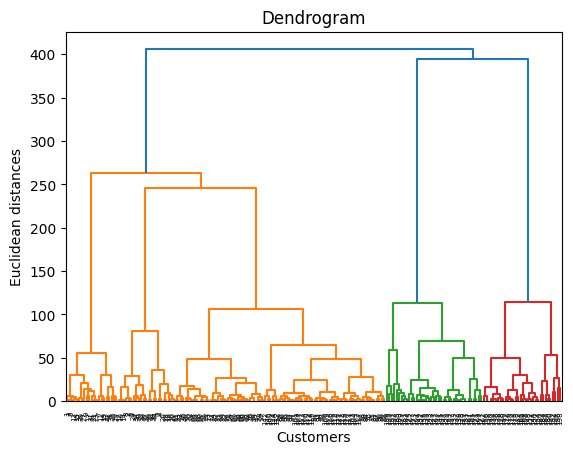

In [3]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

## Training the Hierarchical Clustering model on the dataset

In [5]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, linkage = 'ward')
y_hc = hc.fit_predict(X)

## Visualising the clusters

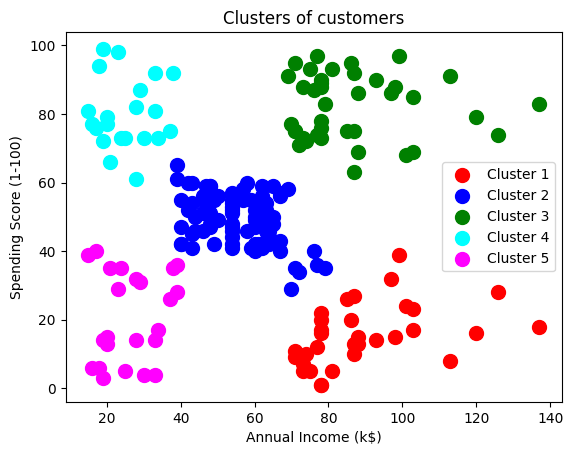

In [6]:
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [7]:
## TEST

## Self-Assessment and Further Exploration

Now that you've performed hierarchical clustering, let's explore some common ways to evaluate and understand your clusters further. Think about what each of these metrics and visualizations tells you about your data.

### 1. Evaluate Clustering Performance: Silhouette Score

The Silhouette Score is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1. A score of 1 means that clusters are well-separated and distinct. A score of 0 means that clusters are indifferent, or that the distance between clusters is not significant. A score of -1 means that clusters are assigned incorrectly.

In [8]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X, y_hc)
print(f"The average silhouette_score for the 5 clusters is: {silhouette_avg:.2f}")

# Optional: You can also visualize individual silhouette scores for more insight
# from sklearn.metrics import silhouette_samples
# sample_silhouette_values = silhouette_samples(X, y_hc)
# print("\nSample silhouette values (first 10):\n", sample_silhouette_values[:10])

The average silhouette_score for the 5 clusters is: 0.55


### 2. Understand Cluster Characteristics: Visualize Cluster Centroids

While `AgglomerativeClustering` doesn't explicitly give centroids, we can calculate the mean of each cluster to get a sense of its central tendency. Add these 'pseudo-centroids' to your visualization.

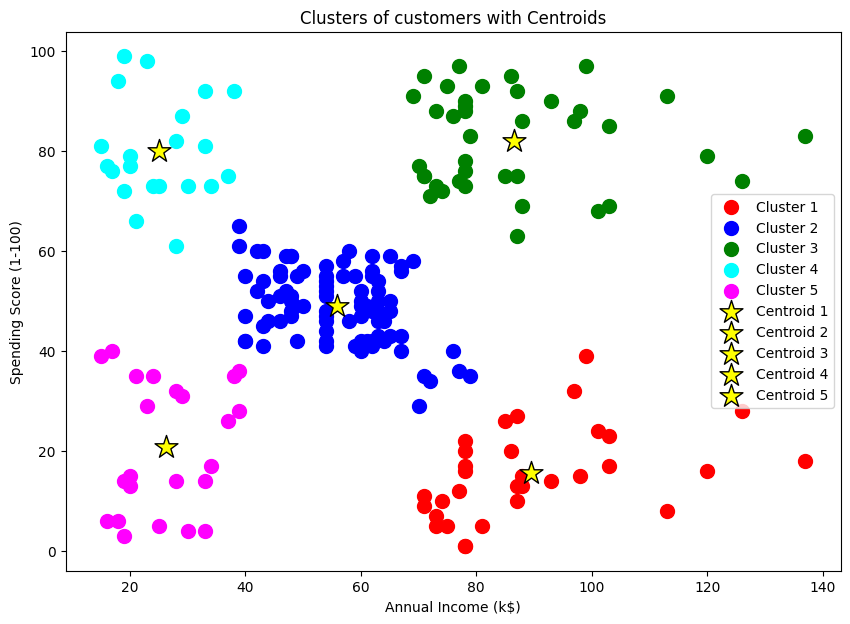

In [9]:
plt.figure(figsize=(10, 7))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')

# Calculate and plot cluster means (pseudo-centroids)
for i in range(5):
    mean_x = X[y_hc == i, 0].mean()
    mean_y = X[y_hc == i, 1].mean()
    plt.scatter(mean_x, mean_y, s=300, c='yellow', marker='*', edgecolor='black', label=f'Centroid {i+1}')

plt.title('Clusters of customers with Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

### 3. Analyze Cluster Sizes

It's often useful to see how many data points fall into each cluster. This can reveal if the clusters are balanced or if some are very small or very large.

In [10]:
from collections import Counter

cluster_counts = Counter(y_hc)
print("Number of data points in each cluster:")
for cluster_id, count in sorted(cluster_counts.items()):
    print(f"Cluster {cluster_id + 1}: {count} data points")

Number of data points in each cluster:
Cluster 1: 32 data points
Cluster 2: 85 data points
Cluster 3: 39 data points
Cluster 4: 21 data points
Cluster 5: 23 data points


### 4. Challenge Yourself: Experiment with Parameters - Example Code

Let's try changing the number of clusters (`n_clusters`) to 3 and observe the new results. Remember, you can modify `n_clusters` to other values as well.

--- Results with 3 Clusters ---
The average silhouette_score for 3 clusters is: 0.46


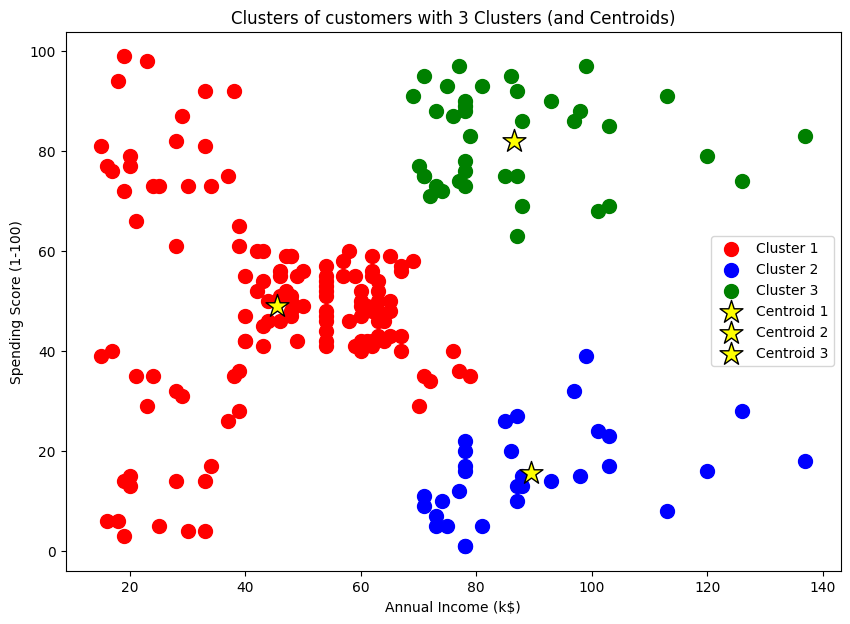


Number of data points in each of the 3 clusters:
Cluster 1: 129 data points
Cluster 2: 32 data points
Cluster 3: 39 data points


In [11]:
# Re-train the Hierarchical Clustering model with a different number of clusters (e.g., 3)
hc_new = AgglomerativeClustering(n_clusters = 3, linkage = 'ward')
y_hc_new = hc_new.fit_predict(X)

print("--- Results with 3 Clusters ---")

# Recalculate Silhouette Score
from sklearn.metrics import silhouette_score
silhouette_avg_new = silhouette_score(X, y_hc_new)
print(f"The average silhouette_score for 3 clusters is: {silhouette_avg_new:.2f}")

# Visualize the new clusters
plt.figure(figsize=(10, 7))
plt.scatter(X[y_hc_new == 0, 0], X[y_hc_new == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_hc_new == 1, 0], X[y_hc_new == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_hc_new == 2, 0], X[y_hc_new == 2, 1], s = 100, c = 'green', label = 'Cluster 3')

# Calculate and plot cluster means (pseudo-centroids) for 3 clusters
for i in range(3):
    mean_x = X[y_hc_new == i, 0].mean()
    mean_y = X[y_hc_new == i, 1].mean()
    plt.scatter(mean_x, mean_y, s=300, c='yellow', marker='*', edgecolor='black', label=f'Centroid {i+1}')

plt.title('Clusters of customers with 3 Clusters (and Centroids)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# Analyze new cluster sizes
from collections import Counter
cluster_counts_new = Counter(y_hc_new)
print("\nNumber of data points in each of the 3 clusters:")
for cluster_id, count in sorted(cluster_counts_new.items()):
    print(f"Cluster {cluster_id + 1}: {count} data points")